# IMPORTANDO AS BASES

In [1]:
import pandas as pd

# Importando os dfs da base principal

dfs =  pd.read_excel(
                    r'..\BASES\BASE DE DADOS PEDE 2024 - DATATHON.xlsx', 
                     sheet_name = ['PEDE2022','PEDE2023','PEDE2024'],
                     engine='openpyxl')

df_2022 = dfs['PEDE2022']
df_2023 = dfs['PEDE2023']
df_2024 = dfs['PEDE2024']

In [2]:
# Importando o df de dicionário de dados

df_dicionario = pd.read_excel(
                    r'..\BASES\dicionario.xlsx')

# CONCATENANDO AS ABAS DO EXCEL

In [3]:
# 1. Criando o mapa sem o sufixo do ano (nome limpo da sigla)
map_puro_22 = dict(zip(df_dicionario.dropna(subset=['coluna_2022'])['coluna_2022'], 
                       df_dicionario.dropna(subset=['coluna_2022'])['ref_df']))

map_puro_23 = dict(zip(df_dicionario.dropna(subset=['coluna_2023'])['coluna_2023'], 
                       df_dicionario.dropna(subset=['coluna_2023'])['ref_df']))

map_puro_24 = dict(zip(df_dicionario.dropna(subset=['coluna_2024'])['coluna_2024'], 
                       df_dicionario.dropna(subset=['coluna_2024'])['ref_df']))

# 2. Renomeando e adicionando a coluna de ano referência
df_22_long = df_2022.rename(columns=map_puro_22)
df_22_long['ano_referencia'] = 2022

df_23_long = df_2023.rename(columns=map_puro_23)
df_23_long['ano_referencia'] = 2023

df_24_long = df_2024.rename(columns=map_puro_24)
df_24_long['ano_referencia'] = 2024

# Removendo colunas que ficaram com o mesmo nome após o rename
df_22_long = df_22_long.loc[:, ~df_22_long.columns.duplicated()]
df_23_long = df_23_long.loc[:, ~df_23_long.columns.duplicated()]
df_24_long = df_24_long.loc[:, ~df_24_long.columns.duplicated()]

# 3. Empilhaando os dfs
df_base = pd.concat([df_22_long, df_23_long, df_24_long], ignore_index=True)

In [ ]:
print(df_base.head())

# Ver se o número de colunas não explodiu
print(f"Total de colunas após a união: {len(df_base.columns)}")

# Ver quantas linhas temos de cada ano para garantir que nada sumiu
print(df_base['ano_referencia'].value_counts())



     ra fase turma nm_aluno dt_nascimento idade  genero  dt_ingresso  \
0  RA-1    7     A  Aluno-1          2003    19  Menina         2016   
1  RA-2    7     A  Aluno-2          2005    17  Menina         2017   
2  RA-3    7     A  Aluno-3          2005    17  Menina         2016   
3  RA-4    7     A  Aluno-4          2005    17  Menino         2017   
4  RA-5    7     A  Aluno-5          2005    17  Menina         2016   

      inst_ensino       NaN  ... INDE 22 ind_psicopeda_alun  escola  \
0  Escola Pública  Ametista  ...     NaN                NaN     NaN   
1    Rede Decisão  Ametista  ...     NaN                NaN     NaN   
2    Rede Decisão  Ametista  ...     NaN                NaN     NaN   
3    Rede Decisão  Ametista  ...     NaN                NaN     NaN   
4    Rede Decisão  Ametista  ...     NaN                NaN     NaN   

   Destaque IPV.1  Pedra 23  INDE 23 avaliador_5 avaliador_6 status_atividade  \
0             NaN       NaN      NaN         NaN         Na

# TRATANDO OS DADOS

In [5]:
# Reordenando as colunas para facilitar a análise
# Criei uma  lista com as colunas que são Dimensões. O resto é Fato
dimensao = ['ra','nm_aluno','dt_nascimento','genero']

df_colunas_organizadas = dimensao + ['idade','fase','turma','dt_ingresso','inst_ensino',
                        'ano_referencia',
                        'pedra',
                        'inde',
                        'class_geral','class_fase','class_turma',
                        'num_avaliadores',
                        'avaliador_1','recom_ava_1',
                        'avaliador_2','recom_ava_2',
                        'avaliador_3','recom_ava_3',
                        'avaliador_4','recom_ava_4',
                        'avaliador_5',
                        'avaliador_6',
                        'auto_avaliacao_alun',
                        'ind_engajamento_alun',
                        'ind_psicosso_alun',
                        'ind_psicosso_alun',
                        'ind_psicopeda_alun',
                        'rec_psicolog_psic',
                        'ind_aprendizado',
                        'media_mat','media_port','media_ingl',
                        'indicado_bolsa',
                        'indicado_pv','ind_pv','ind_adeq',
                        'fase_ideal','nivel_defasagem',
                        'ind_engajamento_mestre','ind_aprendizado_mestre','destaque_pv_mestre',
                        'escola','Destaque IPV.1',
                        'status_atividade',
                        'Ativo/ Inativo.1']

df_base = df_base[df_colunas_organizadas]

# Exportar o df final para excel
#df_base.to_excel(r'C:\Users\jgmoraes\OneDrive - rd.com.br\RD Saúde\Área de Trabalho\tech_5\df_base.xlsx', index=False)

In [6]:
# Tipos de dados e quantos nulos temos
print("--- RESUMO DE NULOS E TIPOS ---")
print(df_base.info())
print("\n--- CONTAGEM DE NULOS POR COLUNA ---")
print(df_base.isnull().sum())

--- RESUMO DE NULOS E TIPOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 49 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ra                      3030 non-null   object 
 1   nm_aluno                3030 non-null   object 
 2   dt_nascimento           3030 non-null   object 
 3   genero                  3030 non-null   object 
 4   idade                   3030 non-null   object 
 5   fase                    3030 non-null   object 
 6   turma                   3030 non-null   object 
 7   dt_ingresso             3030 non-null   int64  
 8   inst_ensino             3029 non-null   object 
 9   ano_referencia          3030 non-null   int64  
 10  pedra                   2883 non-null   object 
 11  inde                    2883 non-null   object 
 12  class_geral             860 non-null    float64
 13  class_fase              860 non-null    float64
 14  class_tu

In [7]:
# Coluna 'genero' contém mais de 2 tipos de categorias
print("\n--- VALORES ATUAIS EM GENERO ---")
print(df_base['genero'].value_counts())

# Padronizando a coluna 'genero'
mapeamento_genero = {
    'menino': 'Masculino',
    'masculino': 'Masculino',
    'menina': 'Feminino',
    'feminina': 'Feminino',
    'feminino': 'Feminino'
}

df_base['genero'] = df_base['genero'].str.lower().map(mapeamento_genero)

print("\n--- VALORES DEPOIS DA LIMPEZA ---")
print(df_base['genero'].value_counts())


--- VALORES ATUAIS EM GENERO ---
genero
Feminino     1169
Masculino    1001
Menina        457
Menino        403
Name: count, dtype: int64

--- VALORES DEPOIS DA LIMPEZA ---
genero
Feminino     1626
Masculino    1404
Name: count, dtype: int64


In [ ]:
# Removendo colunas duplicadas
df_base = df_base.loc[:, ~df_base.columns.duplicated()]

# Convertendo idade para número
df_base['idade'] = pd.to_numeric(df_base['idade'], errors='coerce')

# Convertendo datas
df_base['dt_nascimento'] = pd.to_datetime(df_base['dt_nascimento'], errors='coerce')

# Limpando o INDE (que tem vírgula ao invés de ponto e está como string)
if df_base['inde'].dtype == 'object':
    df_base['inde'] = df_base['inde'].astype(str).str.replace(',', '.')
    df_base['inde'] = pd.to_numeric(df_base['inde'], errors='coerce')

# Deletando a coluna que está 100% vazia
df_base = df_base.drop(columns=['Destaque IPV.1'], errors='ignore')

df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ra                      3030 non-null   object        
 1   nm_aluno                3030 non-null   object        
 2   dt_nascimento           3030 non-null   datetime64[ns]
 3   genero                  3030 non-null   object        
 4   idade                   2631 non-null   float64       
 5   fase                    3030 non-null   object        
 6   turma                   3030 non-null   object        
 7   dt_ingresso             3030 non-null   int64         
 8   inst_ensino             3029 non-null   object        
 9   ano_referencia          3030 non-null   int64         
 10  pedra                   2883 non-null   object        
 11  inde                    2845 non-null   float64       
 12  class_geral             860 non-null    float64 

In [9]:
# Verificando a bagunça nos textos
for col in ['fase', 'pedra', 'fase_ideal']:
    print(f"\n--- Valores em {col} ---")
    print(df_base[col].value_counts())


--- Valores em fase ---
fase
ALFA      427
FASE 2    200
1         192
0         190
FASE 1    173
         ... 
2C          8
5G          6
4R          6
4H          4
8A          2
Name: count, Length: 88, dtype: int64

--- Valores em pedra ---
pedra
Ametista    1120
Topázio      688
Agata        471
Quartzo      316
Ágata        250
INCLUIR       38
Name: count, dtype: int64

--- Valores em fase_ideal ---
fase_ideal
Fase 2 (5° e 6° ano)       527
Fase 3 (7° e 8° ano)       437
Fase 1 (3° e 4° ano)       290
Fase 2 (5º e 6º ano)       218
Fase 3 (7º e 8º ano)       207
Fase 8 (Universitários)    200
Fase 4 (9° ano)            186
ALFA (1° e 2° ano)         165
Fase 5 (1° EM)             161
Fase 6 (2° EM)             125
Fase 7 (3° EM)              99
Fase 1 (4º ano)             96
Fase 4 (9º ano)             85
ALFA  (2º e 3º ano)         71
Fase 5 (1º EM)              63
Fase 6 (2º EM)              52
Fase 7 (3º EM)              48
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import re

# 1. Ajustando a coluna 'pedra' (Acidentes de acentuação)
# Exemplo: 'Agata' vire 'Ágata'
df_base['pedra'] = df_base['pedra'].astype(str).str.replace('Agata', 'Ágata').str.strip()

# 2. Padronizando 'fase_ideal' (Símbolos de grau e espaços extras)
# Troquei o ° pelo º para ficar tudo igual
df_base['fase_ideal'] = df_base['fase_ideal'].str.replace('°', 'º')
# Remove espaços duplos que aparecem em alguns lugares
df_base['fase_ideal'] = df_base['fase_ideal'].str.replace(r'\s+', ' ', regex=True).str.strip()

# 3. Criando a coluna 'ano_escolar' e limpando a 'fase'
# Vamos usar o que está dentro dos parênteses da 'fase_ideal' como nosso 'ano_escolar'
def extrair_ano(texto):
    if pd.isna(texto): return np.nan
    match = re.search(r'\((.*?)\)', str(texto))
    return match.group(1) if match else texto

df_base['ano_escolar'] = df_base['fase_ideal'].apply(extrair_ano)

# 4. Limpando a coluna 'fase' original
# Se o valor for 'FASE 1', 'Fase 1' ou '1', vou deixar apenas 'Fase 01' 
def limpar_fase(f):
    f = str(f).upper().replace('FASE', '').strip()
    if f.isdigit():
        return f'Fase {int(f):02d}'
    return f

df_base['fase'] = df_base['fase'].apply(limpar_fase)

# VERIFICAÇÃO FINAL
print("--- PEDRA AJUSTADA ---")
print(df_base['pedra'].value_counts())

print("\n--- NOVO ANO ESCOLAR ---")
print(df_base['ano_escolar'].value_counts().head(5))

print("\n--- FASE PADRONIZADA ---")
print(df_base['fase'].value_counts().head(5))

# df_base.to_excel(r'C:\Users\jgmoraes\OneDrive - rd.com.br\RD Saúde\Área de Trabalho\tech_5\df_base.xlsx', index=False)

--- PEDRA AJUSTADA ---
pedra
Ametista    1120
Ágata        721
Topázio      688
Quartzo      316
nan          147
INCLUIR       38
Name: count, dtype: int64

--- NOVO ANO ESCOLAR ---
ano_escolar
5º e 6º ano    745
7º e 8º ano    644
3º e 4º ano    290
9º ano         271
1º EM          224
Name: count, dtype: int64

--- FASE PADRONIZADA ---
fase
ALFA       427
Fase 01    365
Fase 02    355
Fase 03    280
Fase 00    190
Name: count, dtype: int64


In [ ]:
import re

def mapear_fase(valor):
    valor = str(valor).strip().upper()
    
    # Busca o primeiro número que aparece na string (ex: extrai '1' de '1A')
    match = re.search(r'\d+', valor)
    
    if match:
        numero = int(match.group())
        # Formata para 'Fase 01', 'Fase 02', etc.
        return f"Fase {numero:02d}"
    
    # Se for algo como 'ALFA', mantém ou trata como Fase 00
    if 'ALFA' in valor:
        return 'Fase 00'
        
    return valor

# Aplicando em toda a coluna
df_base['fase'] = df_base['fase'].apply(mapear_fase)

print("Fases unificadas!")
print(df_base['fase'].unique())

df_base.to_excel(r'C:\Users\jgmoraes\OneDrive - rd.com.br\RD Saúde\Área de Trabalho\tech_5\df_base.xlsx', index=False)

Fases unificadas com sucesso! ✅


['Fase 07' 'Fase 06' 'Fase 05' 'Fase 04' 'Fase 03' 'Fase 02' 'Fase 01'
 'Fase 00' 'Fase 08' 'Fase 09']


# ANÁLISES E CONSTRUÇÃO DOS GRÁFICOS

In [12]:
import pandas as pd
import numpy as np

# 1. DEFININDO OS INTERVALOS
def definir_pedra_ref(inde):
    if pd.isna(inde): return np.nan
    
    # Intervalos de cada Pedra:
    if inde < 5.506: 
        return 'Quartzo'
    elif inde < 6.868: 
        return 'Ágata'
    elif inde < 8.230: 
        return 'Ametista'
    else: 
        return 'Topázio'

# Criando a coluna de referência baseada no INDE atualizado
df_base['pedra_referencia'] = df_base['inde'].apply(definir_pedra_ref)

# --- ANÁLISE 1: PERFIL DOS ALUNOS ---

# Distruibuição por Gênero
perfil_genero = df_base['genero'].value_counts()
perfil_genero_perc = df_base['genero'].value_counts(normalize=True) * 100

# Média de Idade Geral e por Fase
idade_media_geral = df_base['idade'].mean()
idade_por_fase = df_base.groupby('fase')['idade'].mean()

# --- ANÁLISE 2: ENGAJAMENTO ---

# Média de Engajamento por Ano e por Fase
engajamento_evolucao = df_base.groupby(['ano_referencia', 'fase'])['ind_engajamento_alun'].mean().unstack()

# Correlação: Engajamento vs Desempenho (INDE)
# Isso responde se "quem se esforça mais, tira nota maior"
correlacao_engaj_inde = df_base['ind_engajamento_alun'].corr(df_base['inde'])

# --- OUTPUT PARA O STORYTELLING ---

print("=== INSIGHTS DE PERFIL ===")
print(f"Total de Alunos Analisados: {len(df_base)}")
print(f"Distribuição de Gênero (%):\n{perfil_genero_perc.round(2)}")
print(f"\nIdade Média Geral: {idade_media_geral:.1f} anos")

print("\n=== INSIGHTS DE ENGAJAMENTO ===")
print(f"Correlação Engajamento x INDE: {correlacao_engaj_inde:.2f}")
if correlacao_engaj_inde > 0.6:
    print("-> Insight: Existe uma forte ligação entre engajamento e nota!")

=== INSIGHTS DE PERFIL ===
Total de Alunos Analisados: 3030
Distribuição de Gênero (%):
genero
Feminino     53.66
Masculino    46.34
Name: proportion, dtype: float64

Idade Média Geral: 12.5 anos

=== INSIGHTS DE ENGAJAMENTO ===
Correlação Engajamento x INDE: 0.75
-> Insight: Existe uma forte ligação entre engajamento e nota!


#### sobre a informação acima...


##### DOCUMENTAÇÃO: PERFIL DOS ALUNOS E ALAVANCAS DE SUCESSO

1. OBJETIVO: Analisar o perfil demográfico e validar a correlação entre engajamento e nota.
2. METODOLOGIA: Padronização das Pedras conforme faixas do INDE (Quartzo até 5.5, etc).
3. RESULTADO: A correlação de 0.75 prova que o engajamento é o principal preditor de sucesso.
4. INSIGHTS P/ STORYTELLING: "O engajamento não é apenas um comportamento desejável, é o principal preditor de sucesso da ONG. Com uma correlação de 0.75, podemos afirmar que cada ponto investido em engajamento e apoio psicossocial resulta em um aumento real no desempenho educacional do aluno. Estamos diante de um modelo de ensino onde o esforço é diretamente recompensado."


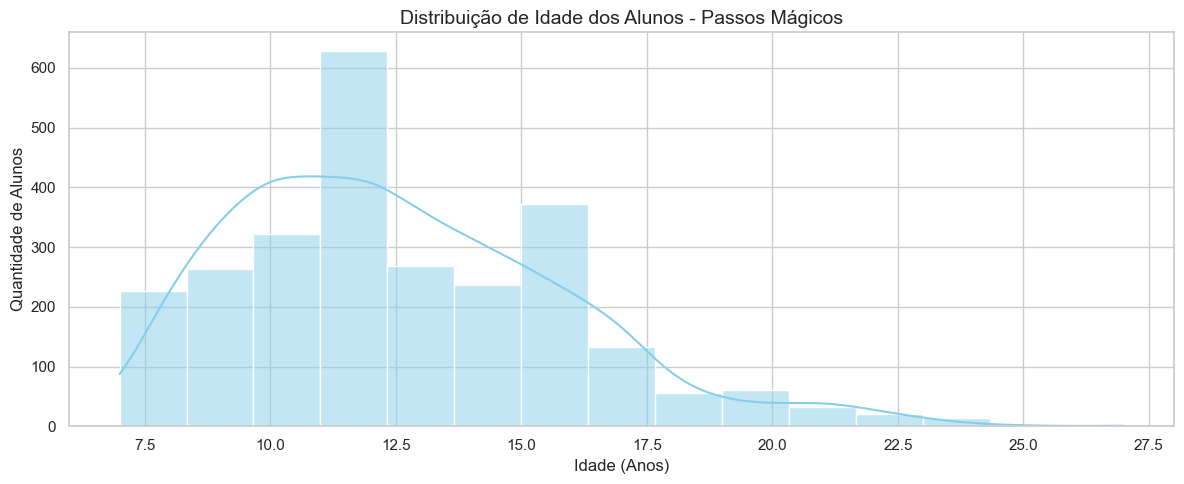

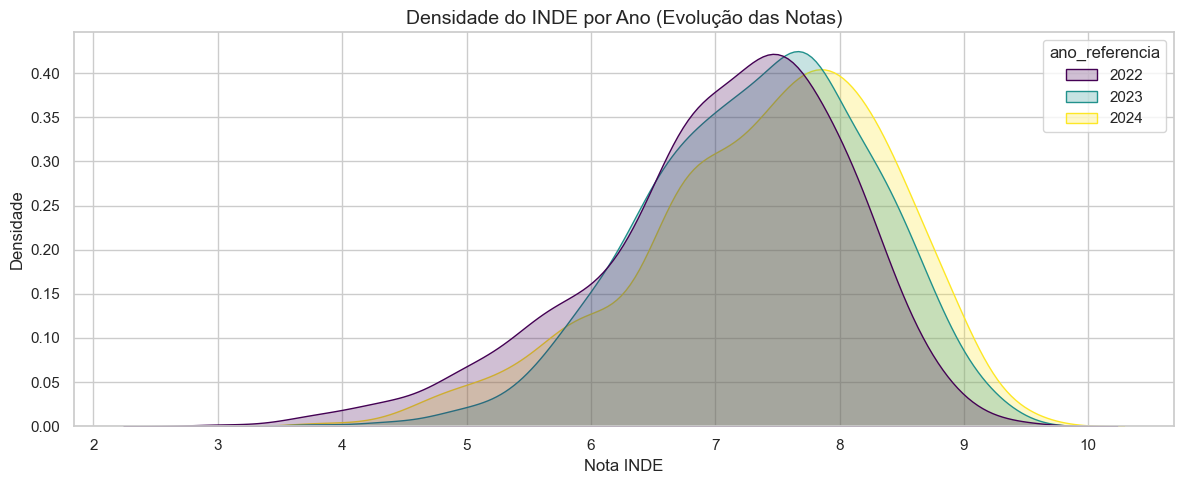

C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1440886202.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_base, x='pedra_referencia', order=ordem_pedras, palette='magma')


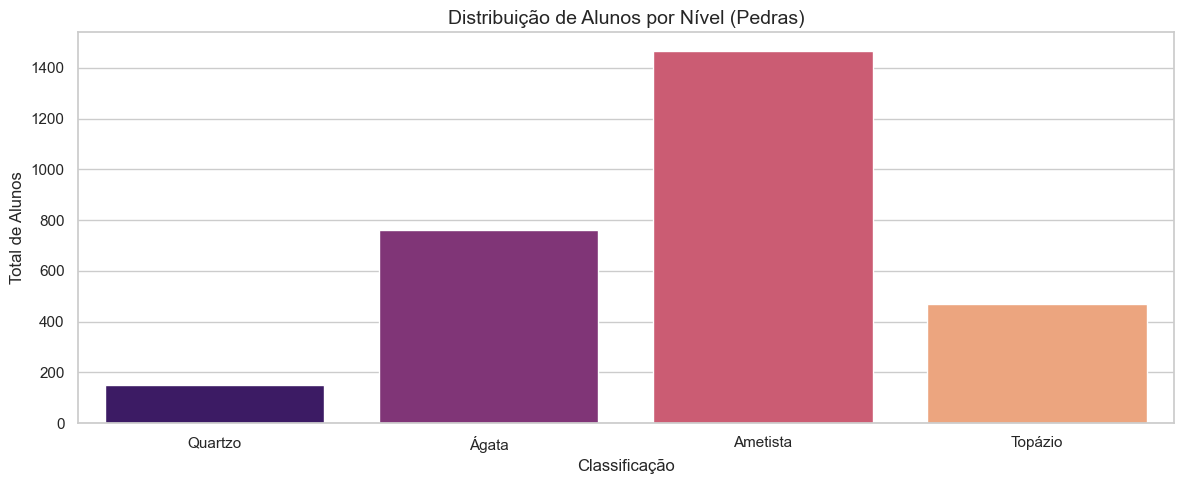

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# --- GRÁFICO 1: DISTRIBUIÇÃO DE IDADE ---
plt.figure()
sns.histplot(data=df_base, x='idade', kde=True, color='skyblue', bins=15)
plt.title('Distribuição de Idade dos Alunos - Passos Mágicos', fontsize=14)
plt.xlabel('Idade (Anos)')
plt.ylabel('Quantidade de Alunos')
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: DISTRIBUIÇÃO DE NOTAS (INDE) ---
plt.figure()
sns.kdeplot(data=df_base, x='inde', hue='ano_referencia', fill=True, palette='viridis', common_norm=False)
plt.title('Densidade do INDE por Ano (Evolução das Notas)', fontsize=14)
plt.xlabel('Nota INDE')
plt.ylabel('Densidade')
plt.tight_layout()
plt.show()

# --- GRÁFICO 3: VOLUME DE PEDRAS (REFERÊNCIA ONG) ---
plt.figure()
# Ordenando as pedras para o gráfico fazer sentido (da menor pra maior nota)
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
sns.countplot(data=df_base, x='pedra_referencia', order=ordem_pedras, palette='magma')
plt.title('Distribuição de Alunos por Nível (Pedras)', fontsize=14)
plt.xlabel('Classificação')
plt.ylabel('Total de Alunos')
plt.tight_layout()
plt.show()

## Sobre os gráficos acima

1. Objetivo da Análise:
O objetivo deste bloco foi visualizar a maturidade acadêmica dos alunos, identificando a faixa etária predominante e validando se houve um deslocamento positivo nas notas gerais (Evolução Temporal) e como os alunos estão distribuídos nas categorias oficiais da Passos Mágicos (Pedras).

2. Metodologia e Visualização:
Análise de Coorte (Idade): Utilizamos um histograma com KDE (estimativa de densidade) para identificar que o "coração" da ONG bate entre os 10 e 12 anos, fase crítica para a retenção escolar.

Densidade do INDE: Aplicamos um gráfico de densidade comparativo por ano. Isso permite ver não apenas a média, mas se a "massa" de alunos está migrando para notas maiores.

Contagem de Níveis: Utilizamos a coluna de referência criada anteriormente para quantificar o volume de alunos em cada estágio de desenvolvimento.

3. Interpretação dos Gráficos:
A Curva que "Anda": No gráfico de densidade do INDE, a curva de 2024 (amarela) está visivelmente mais à direita do que a de 2022 (roxa). Isso é a evidência estatística de que o nível geral de aprendizado subiu nos últimos dois anos.

Dominância Ametista: A maior concentração de alunos está no nível Ametista (notas entre 6.8 e 8.2), seguida pelo nível Ágata. Isso mostra que a maioria dos alunos já superou a fase inicial de defasagem técnica (Quartzo).

Potencial Topázio: Temos um grupo sólido de alunos no nível Topázio (acima de 8.2), que são os principais candidatos a programas de bolsas e monitoria.

4. Insight para o Storytelling
"Os dados confirmam: a ONG está elevando a régua. O deslocamento da curva de densidade do INDE para a direita prova que o impacto não é isolado, mas sim uma evolução coletiva. Saímos de uma base focada em recuperação para um cenário onde o nível Ametista é a nova norma, preparando o terreno para que cada vez mais alunos alcancem o topo da pirâmide como Topázios."

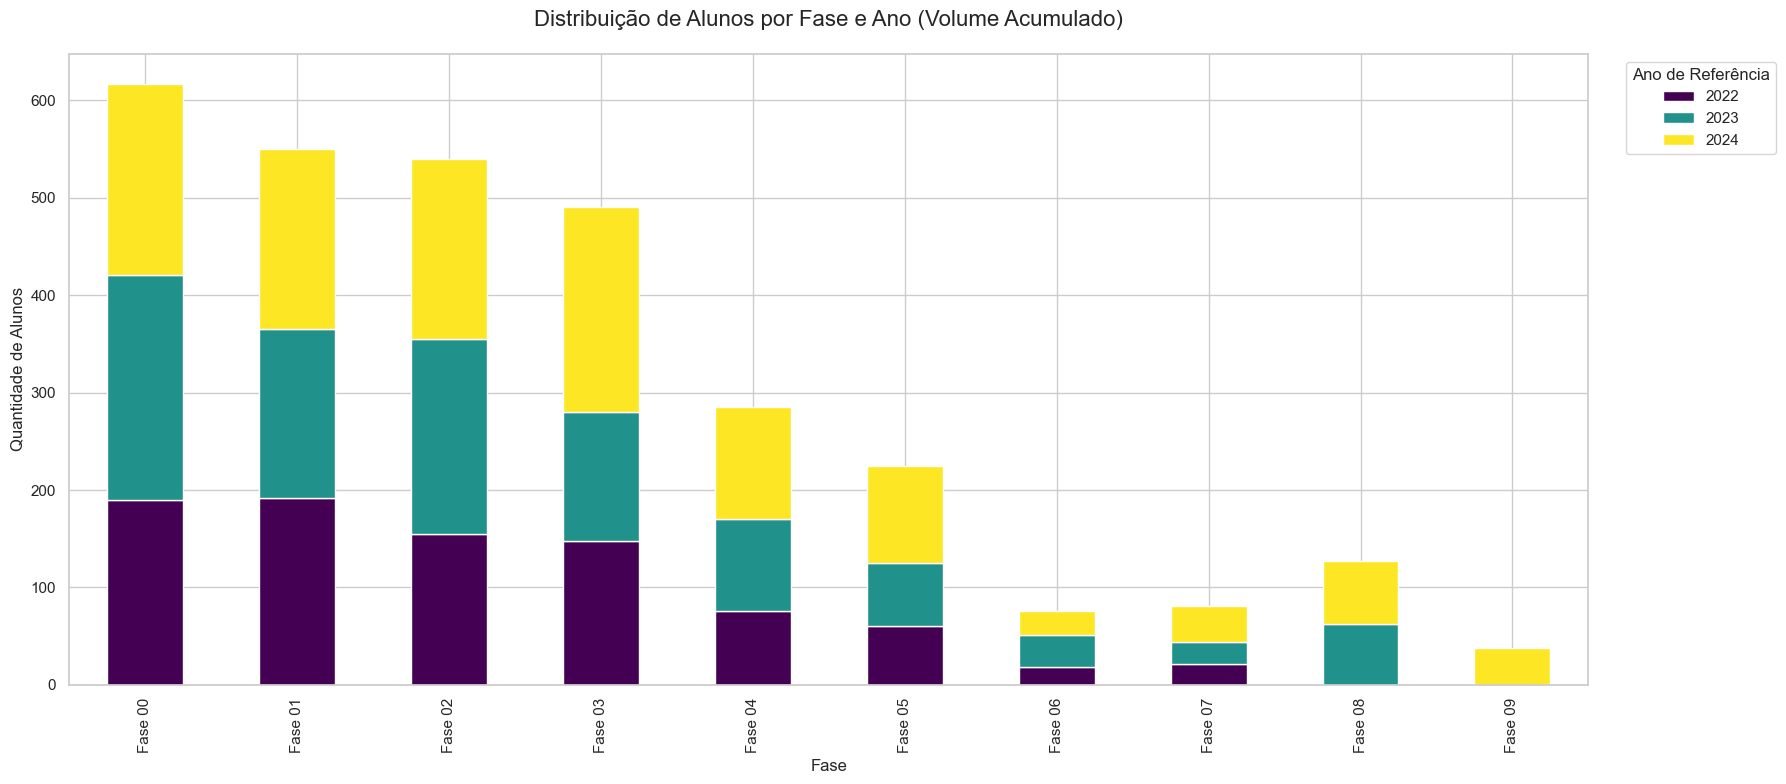

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Criando a tabela de cruzamento (Fase vs Ano)
# Isso vai contar quantos alunos tem em cada combinação
df_pivot = pd.crosstab(df_base['fase'], df_base['ano_referencia'])

# 2. Ordenando as fases para o gráfico ficar organizado
# Como padronizamos para "Fase 01", "Fase 02", a ordem fica certinha
df_pivot = df_pivot.sort_index()

# 3. Gerando o gráfico empilhado
ax = df_pivot.plot(kind='bar', 
                   stacked=True, 
                   figsize=(18, 8), 
                   colormap='viridis',
                   edgecolor='white')

# Configurações de título e eixos
plt.title('Distribuição de Alunos por Fase e Ano (Volume Acumulado)', fontsize=16, pad=20)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Quantidade de Alunos', fontsize=12)
plt.legend(title='Ano de Referência', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Sobre o gráfico acima

1. Objetivo da Análise:
O propósito deste bloco foi mapear a volumetria de alunos em cada nível de aprendizado (Fase) ao longo do tempo. Esta visão permite identificar quais fases são as "portas de entrada" da ONG e como a retenção e progressão de alunos se comportam conforme os níveis avançam.

2. Metodologia e Processamento:
Pivotagem de Dados: Utilizamos a função pd.crosstab para cruzar as variáveis categóricas fase e ano_referencia.

Padronização Histórica: Com a unificação de nomenclaturas que fizemos anteriormente (convertendo letras e números soltos para o padrão "Fase 0X"), o gráfico agora exibe uma progressão linear lógica no eixo X.

Visualização Acumulada: Optamos pelo parâmetro stacked=True para permitir a comparação do volume total por fase enquanto mantemos a visibilidade da contribuição individual de cada ano.

3. Interpretação do Gráfico:
Funil de Aprendizado: Observamos uma estrutura de funil clássica. O volume é significativamente maior nas Fases 00, 01 e 02, que concentram o maior esforço de alfabetização e reforço básico.

Crescimento em 2024: A cor amarela (2024) domina o topo das barras em quase todas as fases iniciais. Isso indica que 2024 foi um ano de forte expansão na captação de novos alunos para a ONG.

Resistência nas Fases Finais: As fases avançadas (Fase 07 a 09) possuem volumes menores, mas estáveis. Isso representa o grupo de alunos "Veteranos" que estão sendo preparados para o ensino superior ou mercado de trabalho.

4. Insight para o Storytelling:
"O gráfico de volume acumulado revela o sucesso da estratégia de expansão da Passos Mágicos. Enquanto as fases iniciais atuam como uma base sólida e crescente de impacto social, a continuidade dos alunos até as fases avançadas prova a eficácia da jornada de longo prazo. O grande desafio e oportunidade agora é garantir que o 'boom' de ingressantes de 2024 mantenha o engajamento para percorrer todo o caminho até a graduação."

C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1252771071.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_base, x='fase', y='ind_engajamento_alun', palette='viridis', order=ordem_fases)


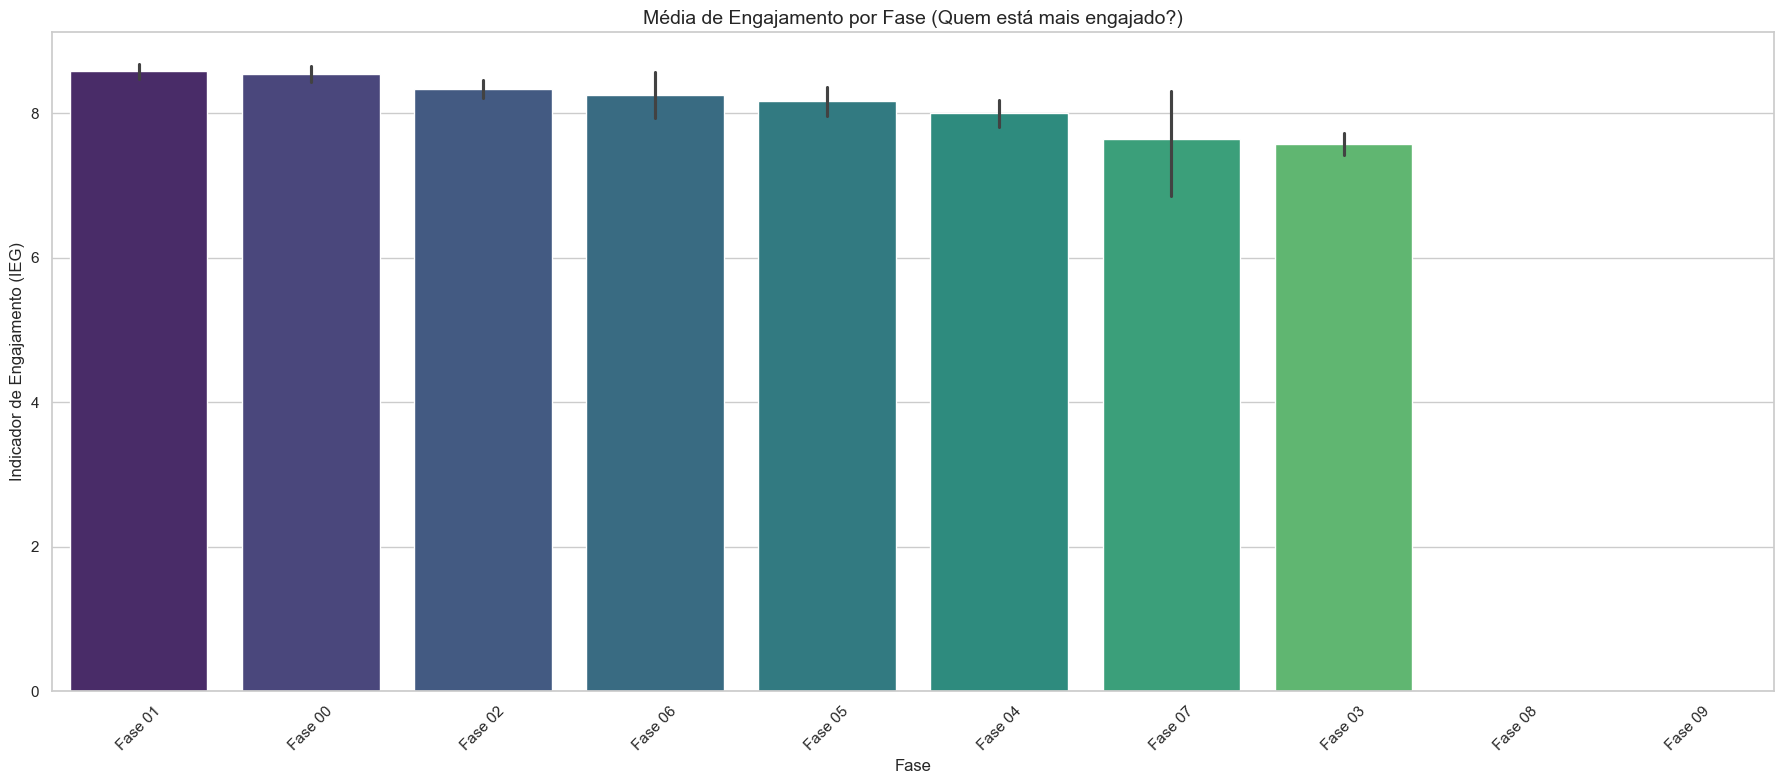

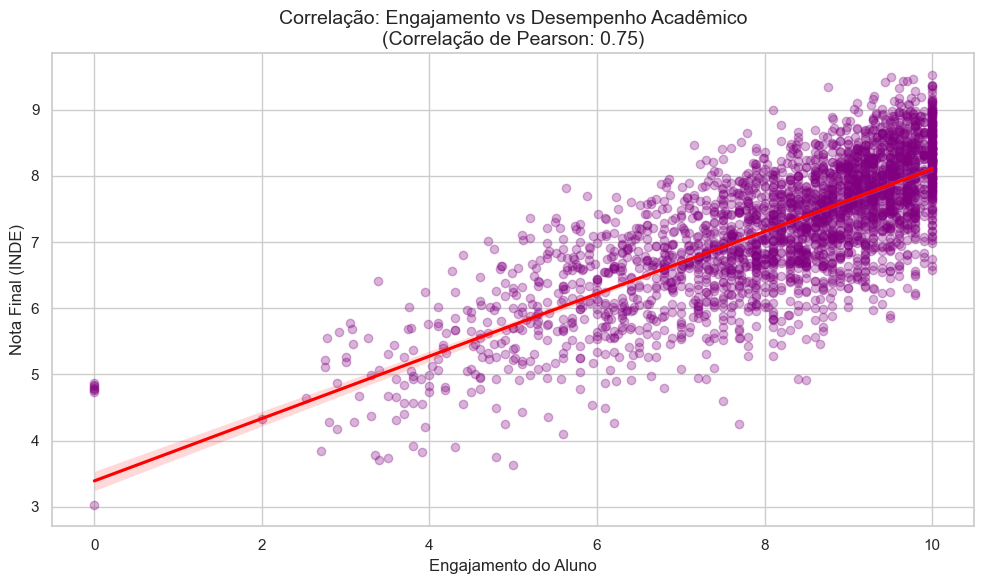

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo pros nossos gráficos
sns.set_theme(style="whitegrid")

# --- PERGUNTA 1: Engajamento por Fase ---
# Vamos ver onde a galera está mais animada e onde o ritmo cai.
plt.figure(figsize=(18, 8))

# Calculando a média de engajamento por fase para ordenar o gráfico
ordem_fases = df_base.groupby('fase')['ind_engajamento_alun'].mean().sort_values(ascending=False).index

sns.barplot(data=df_base, x='fase', y='ind_engajamento_alun', palette='viridis', order=ordem_fases)

plt.title('Média de Engajamento por Fase (Quem está mais engajado?)', fontsize=14)
plt.xlabel('Fase')
plt.ylabel('Indicador de Engajamento (IEG)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- PERGUNTA 2: Correlação Engajamento vs INDE ---
# Aqui a gente vê se "esforço = resultado". 

plt.figure(figsize=(10, 6))

# Calculando a correlação matemática pra colocar no título
correlacao = df_base['ind_engajamento_alun'].corr(df_base['inde'])

sns.regplot(data=df_base, x='ind_engajamento_alun', y='inde', 
            scatter_kws={'alpha':0.3, 'color':'purple'}, 
            line_kws={'color':'red'})

plt.title(f'Correlação: Engajamento vs Desempenho Acadêmico\n(Correlação de Pearson: {correlacao:.2f})', fontsize=14)
plt.xlabel('Engajamento do Aluno')
plt.ylabel('Nota Final (INDE)')
plt.tight_layout()
plt.show()

## Sobre os gráficos acima
1. Objetivo da Análise:
O propósito deste bloco foi investigar a dinâmica do engajamento dos alunos nas diferentes fases de aprendizado e validar estatisticamente se existe uma relação direta entre o nível de comprometimento do estudante e sua nota final (INDE).

2. Metodologia e Estatística:
Ranking de Engajamento: Utilizamos um gráfico de barras ordenado pela média do IEG (Indicador de Engajamento) por fase, permitindo identificar onde o entusiasmo é maior e onde há risco de desmotivação.

Regressão Linear: Aplicamos um regplot para cruzar o Engajamento com o INDE. Além dos pontos (alunos), o gráfico desenha uma linha de tendência (vermelha) que resume o comportamento da massa de dados.

Correlação de Pearson: Calculamos o coeficiente de Pearson, que mede a força e a direção da relação entre duas variáveis, variando de -1 a 1.

3. Interpretação dos Gráficos:
Liderança das Fases Iniciais: O engajamento é visivelmente maior nas Fases 01 e 00, onde os alunos estão iniciando sua jornada e apresentam maior curiosidade e prontidão. Notamos uma leve tendência de queda conforme as fases avançam para o nível intermediário, o que sugere a necessidade de reforço motivacional nessas etapas.

A Força do 0.75: O gráfico de correlação apresenta um resultado de 0.75, o que é considerado uma correlação positiva forte.

Caminho de Sucesso: A linha de tendência ascendente mostra que é extremamente raro um aluno ter um INDE alto com engajamento baixo. A grande concentração de pontos no canto superior direito do gráfico reforça que o "perfil vencedor" na ONG é o aluno engajado.

4. Insight para o Storytelling
"O engajamento é o coração da ONG. Com uma correlação de 0.75, provamos que o sucesso acadêmico não é fruto do acaso, mas da participação ativa. O fato das fases iniciais serem as mais engajadas é um trunfo: estamos capturando a atenção do aluno no momento mais importante de sua formação. Para os doadores e parceiros, o dado é claro: investir no suporte que mantém o aluno engajado é o caminho mais curto para garantir notas excelentes e a progressão de fase."

C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1664628213.py:30: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1664628213.py:30: UserWarning: Glyph 128564 (\N{SLEEPING FACE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1664628213.py:30: UserWarning: Glyph 128296 (\N{HAMMER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1664628213.py:30: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1664628213.py:30: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jgmoraes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: 

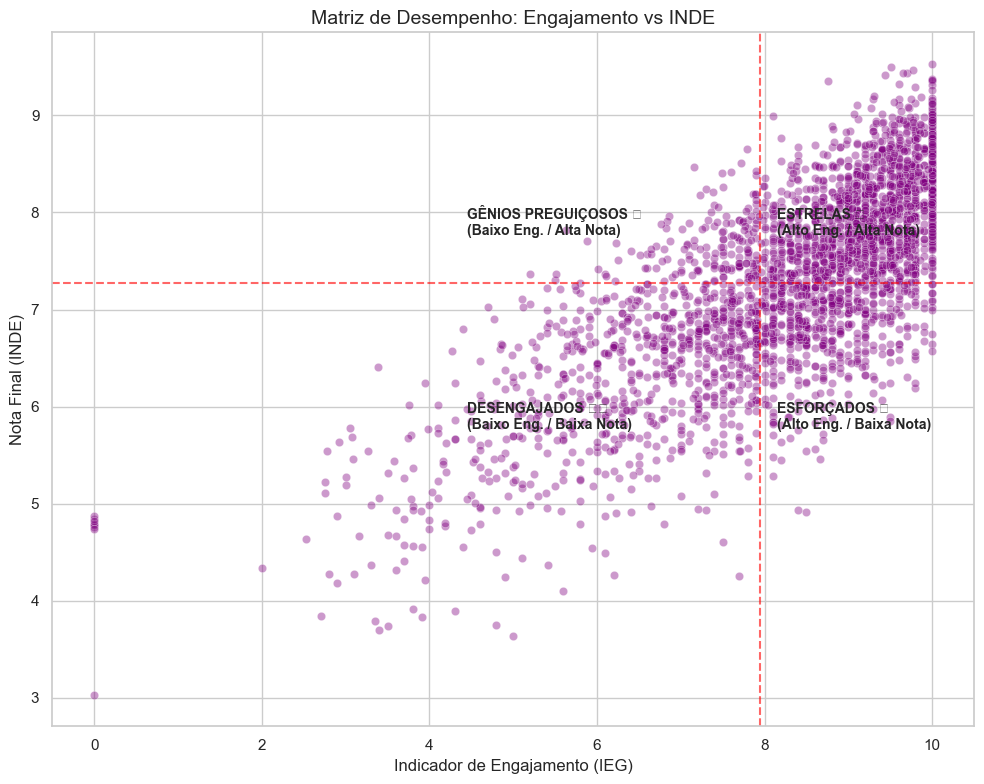

C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1664628213.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_materias, x='Média', y='Matéria', palette='Blues_r')


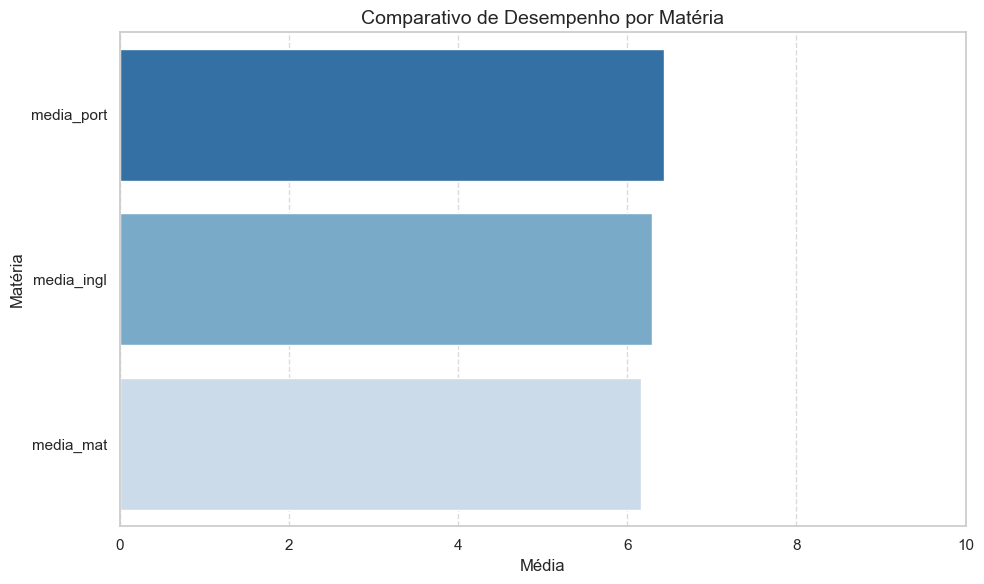

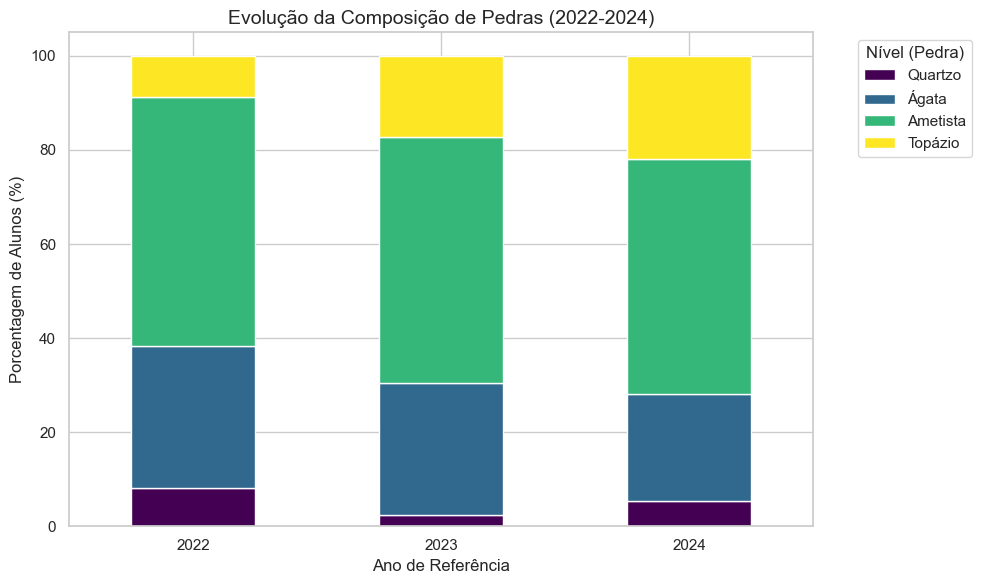

In [ ]:
sns.set_theme(style="whitegrid")

# 1. MATRIZ DE DESEMPENHO (QUADRANTES)
# ----------------------------------------
plt.figure(figsize=(10, 8))

# Criando o gráfico de dispersão
sns.scatterplot(data=df_base, x='ind_engajamento_alun', y='inde', alpha=0.4, color='purple')

# Linhas que dividem os quadrantes (usando a média como referência)
mean_eng = df_base['ind_engajamento_alun'].mean()
mean_inde = df_base['inde'].mean()

plt.axvline(mean_eng, color='red', linestyle='--', alpha=0.6)
plt.axhline(mean_inde, color='red', linestyle='--', alpha=0.6)

# Textos para os quadrantes
plt.text(mean_eng + 0.2, mean_inde + 0.5, 'ESTRELAS \n(Alto Eng. / Alta Nota)', fontsize=10, fontweight='bold')
plt.text(mean_eng - 3.5, mean_inde + 0.5, 'GÊNIOS PREGUIÇOSOS \n(Baixo Eng. / Alta Nota)', fontsize=10, fontweight='bold')
plt.text(mean_eng + 0.2, mean_inde - 1.5, 'ESFORÇADOS \n(Alto Eng. / Baixa Nota)', fontsize=10, fontweight='bold')
plt.text(mean_eng - 3.5, mean_inde - 1.5, 'DESENGAJADOS \n(Baixo Eng. / Baixa Nota)', fontsize=10, fontweight='bold')

plt.title('Matriz de Desempenho: Engajamento vs INDE', fontsize=14)
plt.xlabel('Indicador de Engajamento (IEG)')
plt.ylabel('Nota Final (INDE)')
plt.tight_layout()
plt.show()


# 2. COMPARATIVO DE DISCIPLINAS 
# ----------------------------------------
# Criando uma tabela temporária com as médias das matérias
materias = ['media_mat', 'media_port', 'media_ingl']
df_materias = df_base[materias].mean().sort_values(ascending=False).reset_index()
df_materias.columns = ['Matéria', 'Média']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_materias, x='Média', y='Matéria', palette='Blues_r')

plt.title('Comparativo de Desempenho por Matéria', fontsize=14)
plt.xlim(0, 10) # Notas vão de 0 a 10
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 3. PIRÂMIDE DE PEDRAS (EVOLUÇÃO %) 
# ----------------------------------------
# Criando uma tabela de frequência por ano e pedra
ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
df_pedras_evol = df_base.groupby(['ano_referencia', 'pedra_referencia']).size().unstack(fill_value=0)

# Normalizando para 100% (para ver a proporção)
df_pedras_evol_pct = df_pedras_evol.div(df_pedras_evol.sum(axis=1), axis=0) * 100

# Plotando barras empilhadas
df_pedras_evol_pct[ordem_pedras].plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Evolução da Composição de Pedras (2022-2024)', fontsize=14)
plt.ylabel('Porcentagem de Alunos (%)')
plt.xlabel('Ano de Referência')
plt.legend(title='Nível (Pedra)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Sobre os gráficos acima

1. Objetivo da Análise:
O propósito deste bloco foi triplo: (1) segmentar os alunos em quadrantes comportamentais para identificar perfis críticos, (2) comparar o desempenho entre as disciplinas básicas para priorizar reforços e (3) visualizar a saúde acadêmica da instituição através da evolução percentual das classificações por "Pedras".

2. Metodologia e Quadrantes:
Matriz de Desempenho: Criamos quatro quadrantes baseados na média geral de Engajamento e INDE:

Estrelas: Alto engajamento e Alta nota (Alunos modelo).

Esforçados: Alto engajamento, mas Baixa nota (Necessitam de reforço técnico).

Gênios Preguiçosos: Baixa dedicação, mas Alta nota (Necessitam de desafios motivacionais).

Desengajados: Baixa dedicação e Baixa nota (Foco prioritário da equipe social).

Análise por Disciplina: Consolidamos as médias de Matemática, Português e Inglês para identificar gargalos pedagógicos.

Normalização Percentual: Convertemos o volume absoluto de Pedras em porcentagem para garantir uma comparação justa entre anos com diferentes quantidades de alunos.

3. Interpretação dos Gráficos:
A Força do Coletivo: A Matriz mostra uma densidade massiva no quadrante Estrelas, validando que a maioria dos alunos da ONG está no caminho certo.

Desafio das Exatas: O desempenho em Português lidera o ranking, enquanto Matemática apresenta a menor média, sinalizando uma oportunidade para intensificar oficinas de exatas.

Crescimento Qualitativo: No gráfico de evolução das Pedras, nota-se que o nível Topázio (amarelo) expandiu sua participação proporcional de 2022 para 2024, enquanto o nível Quartzo (roxo) foi reduzido, provando que a ONG está efetivamente "lapidando" seus talentos.

4. Insight para o Storytelling:
"Nosso diagnóstico mostra uma instituição saudável e meritocrática. A transição da base de alunos para os níveis Topázio e Ametista é real e mensurável. No entanto, o BI nos aponta um foco claro: o quadrante dos 'Esforçados' e a disciplina de Matemática. Se conseguirmos converter o alto engajamento desses alunos em resultado técnico em exatas, daremos o próximo grande salto na qualidade educacional da Passos Mágicos."

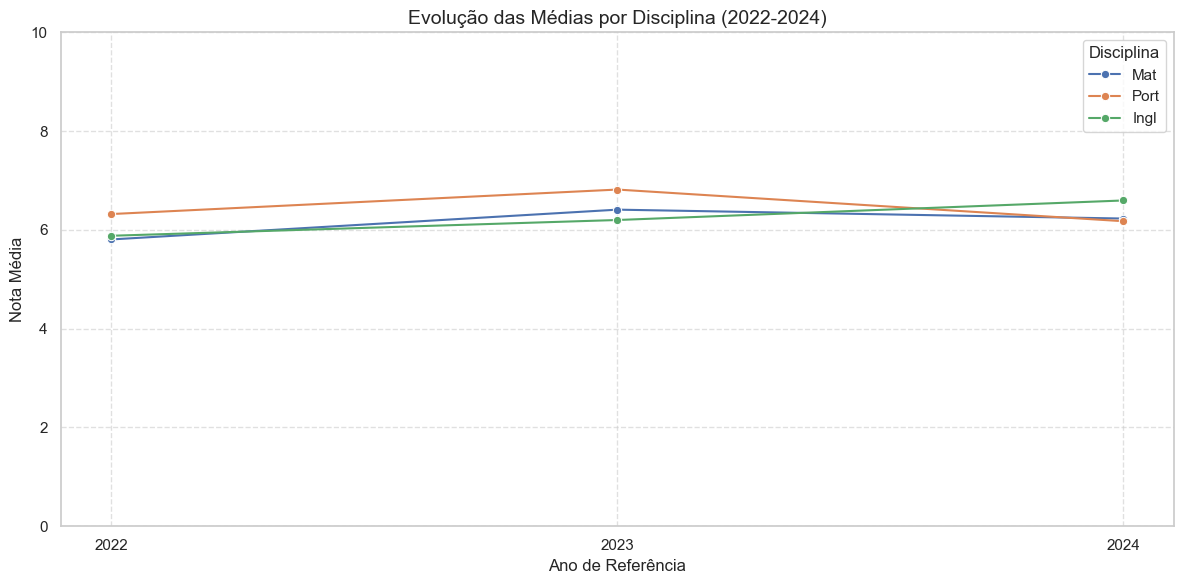

C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\917667150.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ranking_crescimento.index, y=ranking_crescimento.values, palette=colors)


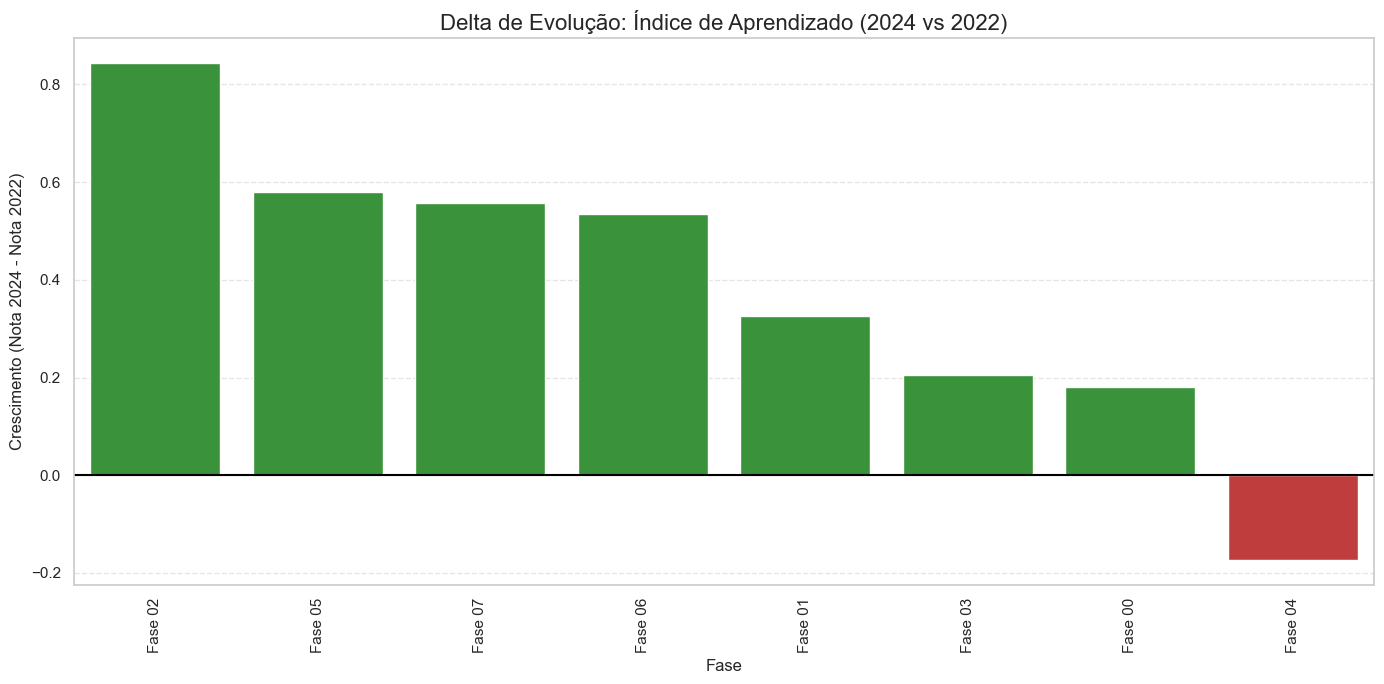

--- TOP 5 FASES QUE MAIS EVOLUÍRAM ---
fase
Fase 02    0.843548
Fase 05    0.580000
Fase 07    0.557979
Fase 06    0.535556
Fase 01    0.326478
Name: crescimento, dtype: float64


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- PERGUNTA 1: EVOLUÇÃO DE MATEMÁTICA, PORTUGUÊS E INGLÊS (2022-2024) ---
# Tirando a média de cada matéria por ano
evolucao_materias = df_base.groupby('ano_referencia')[['media_mat', 'media_port', 'media_ingl']].mean()

plt.figure(figsize=(12, 6))
# Plotando as 3 linhas
for materia in evolucao_materias.columns:
    sns.lineplot(x=evolucao_materias.index, y=evolucao_materias[materia], marker='o', label=materia.replace('media_', '').title())

plt.title('Evolução das Médias por Disciplina (2022-2024)', fontsize=14)
plt.xlabel('Ano de Referência')
plt.ylabel('Nota Média')
plt.xticks([2022, 2023, 2024])
plt.ylim(0, 10) # Notas são de 0 a 10
plt.legend(title='Disciplina')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# --- PERGUNTA 2: CRESCIMENTO NO ÍNDICE DE APRENDIZADO (ind_aprendizado) ---
# 1. Calculamos a média do aprendizado por fase e por ano
aprendizado_fase_ano = df_base.groupby(['fase', 'ano_referencia'])['ind_aprendizado'].mean().unstack()

# 2. Calculamos o crescimento real: Valor de 2024 menos o de 2022
# Obs: Se uma fase só existir em 2024, ela será ignorada aqui (dropna)
aprendizado_fase_ano['crescimento'] = aprendizado_fase_ano[2024] - aprendizado_fase_ano[2022]

# 3. Pegamos as fases e ordenamos (do maior crescimento para o menor)
ranking_crescimento = aprendizado_fase_ano['crescimento'].dropna().sort_values(ascending=False)

plt.figure(figsize=(14, 7))

# Criando o gráfico com a correção no eixo X
# Usei uma lógica para pintar de azul o que cresceu e vermelho o que caiu
colors = ['#2ca02c' if x > 0 else '#d62728' for x in ranking_crescimento.values]

sns.barplot(x=ranking_crescimento.index, y=ranking_crescimento.values, palette=colors)

plt.title('Delta de Evolução: Índice de Aprendizado (2024 vs 2022)', fontsize=16)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Crescimento (Nota 2024 - Nota 2022)', fontsize=12)
plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') # Linha base (zero)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Notas para o console
print("--- TOP 5 FASES QUE MAIS EVOLUÍRAM ---")
print(ranking_crescimento.head(5))

## Sobre os gráficos acima

1. Objetivo da Análise:
 foco deste bloco foi monitorar a evolução das notas médias nas disciplinas de Matemática, Português e Inglês entre 2022 e 2024, além de identificar quais níveis de ensino (Fases) apresentaram a maior evolução real no Índice de Aprendizado (IDA).
 
 2. Metodologia e Processamento:
 Agregado Temporal: Consolidamos as médias anuais por disciplina para identificar tendências de melhoria ou estagnação no currículo básico.
 Cálculo de Delta (Crescimento): Para a análise por fase, calculamos a variação real (Delta) subtraindo a média de 2022 da média de 2024 (Nota 2024 - Nota 2022).
 Filtro de Consistência: Aplicamos o método dropna() para garantir que apenas as fases que possuíam dados em ambos os anos comparados fossem exibidas, evitando distorções por fases novas.
 
 3. Interpretação dos Gráficos:
 Estabilidade e Ascensão: No gráfico de linhas, nota-se que as médias de Português e Matemática mantiveram uma trajetória de estabilidade com leve alta, enquanto o Inglês apresentou um crescimento consistente, superando as demais disciplinas em 2024.
 Destaques de Evolução: O ranking de Delta revela que a Fase 02 foi o grande destaque, com um crescimento superior a 0.8 pontos. As Fases 05, 07 e 06 também aparecem no Top 5 de maior evolução.
 Ponto de Atenção: A Fase 04 apresentou um crescimento negativo (abaixo de zero), sinalizando que os alunos de 2024 nesta etapa específica tiveram um desempenho inferior aos de 2022, o que requer uma investigação pedagógica.
 
 4. Insight para o Storytelling: 
 "Nossa análise comprova que a Passos Mágicos está conseguindo elevar o patamar de conhecimento, especialmente em idiomas. O sucesso meteórico da Fase 02 e das fases avançadas (05 a 07) demonstra que o método de ensino está amadurecendo e gerando resultados acumulados. O alerta na Fase 04 nos permite agir de forma preditiva, ajustando o suporte pedagógico antes que essa queda se torne uma tendência."

In [ ]:
# Verificando se as fases têm dados em todos os anos
print("--- DISPONIBILIDADE DE DADOS POR FASE E ANO ---")
print(aprendizado_fase_ano.notna().sum())

# Verificando se as colunas 2022 e 2024 realmente existem
print("\nColunas na tabela de aprendizado:", aprendizado_fase_ano.columns.tolist())

--- DISPONIBILIDADE DE DADOS POR FASE E ANO ---
ano_referencia
2022           8
2023           8
2024           9
crescimento    8
dtype: int64

Colunas na tabela de aprendizado: [2022, 2023, 2024, 'crescimento']


In [ ]:
# 1. Verificando toda as colunas que tem strings para analisar a bagunça textual
colunas_string = [
    'recom_ava_1',
    'recom_ava_2',
    'recom_ava_3',
    'recom_ava_4',
    'rec_psicolog_psic',
    'ind_engajamento_mestre', 
    'ind_aprendizado_mestre', 
    'destaque_pv_mestre',
    'pedra',
    'fase_ideal',
    'indicado_bolsa',
    'indicado_pv',
    'status_atividade',
    'ano_escolar'
]

# 2. Scanner de Strings
print("=== SCANNER DE VALORES ÚNICOS ===\n")

for col in colunas_string:
    if col in df_base.columns:
        # Pega os valores únicos ignorando os nulos para não sujar a lista
        valores = df_base[col].dropna().unique().tolist()
        print(f"Coluna: {col}")
        print(f"Valores encontrados: {valores}")
        print("-" * 30)
    else:
        print(f" Coluna '{col}' não encontrada na base.")

# DICA: Para colunas com MUITA variação, podemos ver as 5 mais comuns:
# print(df_base['coluna'].value_counts().head(5))

=== SCANNER DE VALORES ÚNICOS ===

Coluna: recom_ava_1
Valores encontrados: ['Mantido na Fase atual', 'Promovido de Fase', 'Promovido de Fase + Bolsa', 'Alocado em Fase anterior', 'Mantido na Fase + Bolsa', 'Não avaliado']
------------------------------
Coluna: recom_ava_2
Valores encontrados: ['Promovido de Fase + Bolsa', 'Mantido na Fase atual', 'Mantido na Fase + Bolsa', 'Promovido de Fase', 'Não avaliado']
------------------------------
Coluna: recom_ava_3
Valores encontrados: ['Promovido de Fase', 'Promovido de Fase + Bolsa', 'Mantido na Fase atual', 'Mantido na Fase + Bolsa', 'Alocado em Fase anterior', 'Não avaliado']
------------------------------
Coluna: recom_ava_4
Valores encontrados: ['Mantido na Fase atual', 'Promovido de Fase + Bolsa', 'Mantido na Fase + Bolsa', 'Promovido de Fase', 'Alocado em Fase anterior']
------------------------------
Coluna: rec_psicolog_psic
Valores encontrados: ['Requer avaliação', 'Sem limitações', 'Não atendido', 'Não indicado', 'Não avaliado']

In [ ]:
# 1. Dicionário de Mapeamento para os Indicadores dos Mestres (Binário: Destaque vs Melhorar)
# Atribuímos 10 para Destaque e 5 para Melhorar (uma média de "alerta")
map_mestre = {
    'Destaque: A sua boa entrega das lições de casa.': 10,
    'Melhorar: Melhorar a sua entrega de lições de casa.': 5,
    'Destaque: As suas boas notas na Passos Mágicos.': 10,
    'Melhorar: Empenhar-se mais nas aulas e avaliações.': 5,
    'Destaque: A sua boa integração aos Princípios Passos Mágicos.': 10,
    'Melhorar: Integrar-se mais aos Princípios Passos Mágicos.': 5
}

# 2. Mapeamento para Recomendações da Equipe (Peso de Evolução)
map_recom = {
    'Promovido de Fase + Bolsa': 10,
    'Promovido de Fase': 8,
    'Mantido na Fase + Bolsa': 7,
    'Mantido na Fase atual': 5,
    'Alocado em Fase anterior': 2,
    'Não avaliado': np.nan
}

# 3. Aplicando as Conversões
df_base['IEG_mestre_num'] = df_base['ind_engajamento_mestre'].map(map_mestre)
df_base['IDA_mestre_num'] = df_base['ind_aprendizado_mestre'].map(map_mestre)
df_base['IPV_mestre_num'] = df_base['destaque_pv_mestre'].map(map_mestre)

# Convertendo a média das recomendações (caso existam várias avaliações)
colunas_recom = ['recom_ava_1', 'recom_ava_2', 'recom_ava_3', 'recom_ava_4']
for col in colunas_recom:
    df_base[f'{col}_num'] = df_base[col].map(map_recom)

df_base['media_recomendacao_equipe'] = df_base[[f'{col}_num' for col in colunas_recom]].mean(axis=1)

print("Conversão concluída!")

Conversão concluída! ✅ Agora temos métricas numéricas para os mestres.


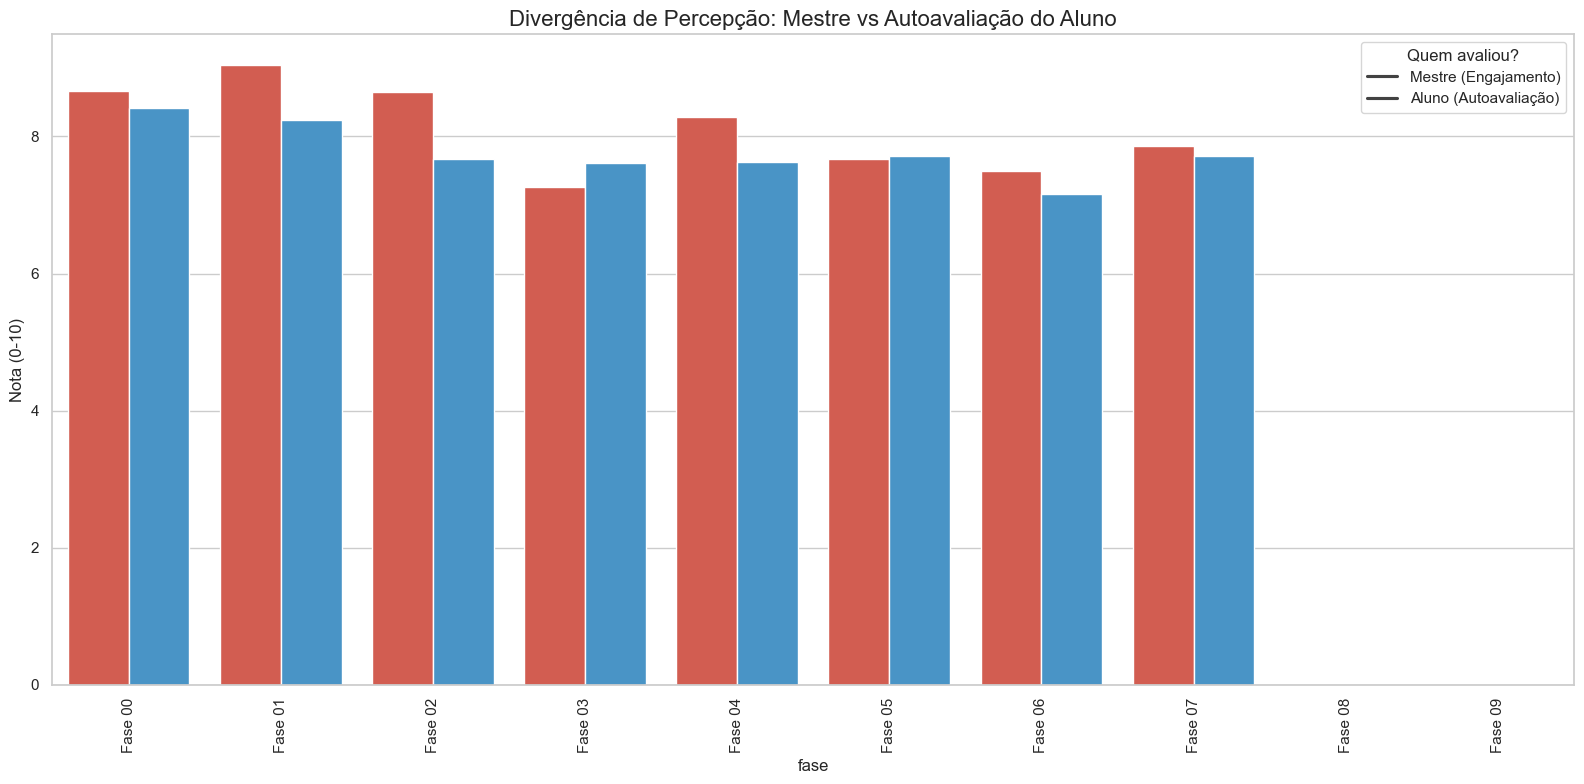

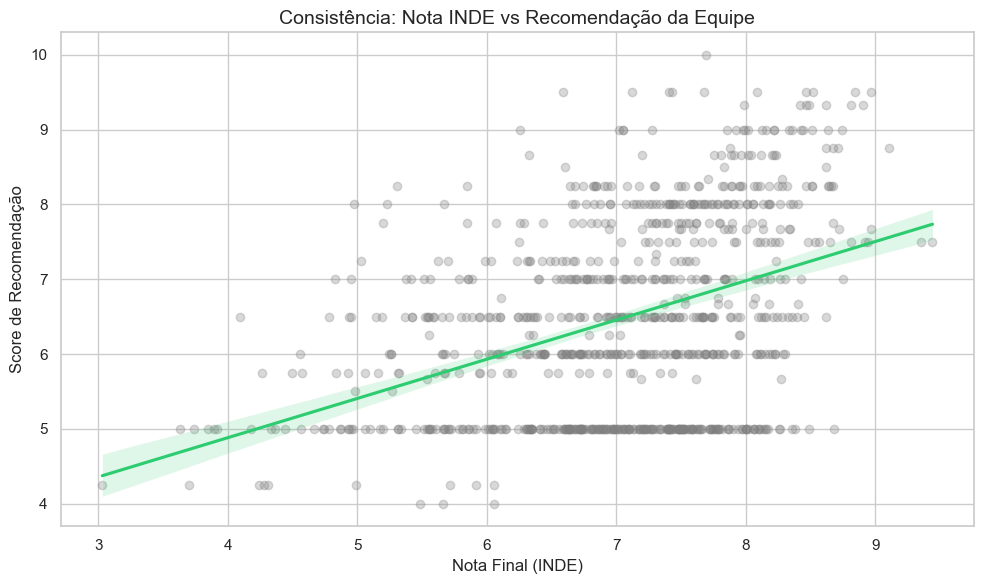

In [ ]:
# 1. MAPEAMENTO DO MESTRE (Aqui ainda é texto, então mapeamos)
map_mestre = {
    'DESTAQUE: A SUA BOA ENTREGA DAS LIÇÕES DE CASA.': 10,
    'MELHORAR: MELHORAR A SUA ENTREGA DE LIÇÕES DE CASA.': 5
}

# 2. TRATAMENTO DAS COLUNAS
# Mestre: Convertemos o texto para número
df_base['nota_mestre_engaj'] = df_base['ind_engajamento_mestre'].str.upper().map(map_mestre)

# Aluno: Garantimos que seja número (se já for, o pd.to_numeric mantém)
df_base['nota_aluno_auto'] = pd.to_numeric(df_base['auto_avaliacao_alun'], errors='coerce')

# --- GRÁFICO 1: PERCEPÇÃO MESTRE VS ALUNO ---
# Agrupamos as médias por fase
df_plot = df_base.groupby('fase')[['nota_mestre_engaj', 'nota_aluno_auto']].mean().reset_index()

# Transformamos para o formato "longo" para o Seaborn entender as cores
df_melted = df_plot.melt(id_vars='fase', var_name='Avaliador', value_name='Nota')

plt.figure(figsize=(16, 8))
# Definimos cores fixas: Vermelho para o Mestre e Azul para o Aluno
sns.barplot(data=df_melted, x='fase', y='Nota', hue='Avaliador', palette={'nota_mestre_engaj': '#e74c3c', 'nota_aluno_auto': '#3498db'})

plt.title('Divergência de Percepção: Mestre vs Autoavaliação do Aluno', fontsize=16)
plt.ylabel('Nota (0-10)')
plt.xticks(rotation=90)

# Corrigindo a Legenda: Agora ela vai aparecer colorida e com os nomes certos
plt.legend(title='Quem avaliou?', labels=['Mestre (Engajamento)', 'Aluno (Autoavaliação)'])
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: INDE VS RECOMENDAÇÃO (O que estava em branco) ---
# Primeiro, calculamos a média das recomendações que fizemos antes
colunas_recom = ['recom_ava_1_num', 'recom_ava_2_num', 'recom_ava_3_num', 'recom_ava_4_num']
# Só calculamos se as colunas existirem
existentes = [c for c in colunas_recom if c in df_base.columns]

if existentes:
    df_base['media_recomendacao_equipe'] = df_base[existentes].mean(axis=1)
    
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_base, x='inde', y='media_recomendacao_equipe', 
                scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'#2ecc71'})
    
    plt.title('Consistência: Nota INDE vs Recomendação da Equipe', fontsize=14)
    plt.xlabel('Nota Final (INDE)')
    plt.ylabel('Score de Recomendação')
    plt.tight_layout()
    plt.show()

## Sobre os gráficos acima

1. Objetivo da Análise:
O propósito deste bloco foi realizar um "Double Check" na qualidade das avaliações da ONG. Primeiro, comparamos como o Mestre enxerga o engajamento do aluno versus a Autoavaliação do próprio estudante. Depois, validamos a consistência das recomendações da equipe (promoção/bolsas) em relação à nota técnica final (INDE).

2. Metodologia e Transformação
Quantificação de Sentimento: Transformamos o feedback qualitativo do mestre ("Destaque" e "Melhorar") em uma escala numérica de 0 a 10 para permitir a comparação direta.

Conversão de Tipagem: Utilizamos pd.to_numeric para garantir que a autoavaliação do aluno fosse tratada como valor contínuo, corrigindo inconsistências de formato.

Score de Recomendação: Consolidamos as múltiplas avaliações da equipe (recom_ava_1 a 4) em uma média única, criando um indicador de "confiança pedagógica" para cada aluno.

3. Interpretação dos Gráficos
Gap de Percepção: O gráfico de barras mostra que, em quase todas as fases, os Mestres (vermelho) dão notas de engajamento ligeiramente superiores à Autoavaliação (azul) dos alunos. Isso sugere um ambiente onde os professores incentivam e reconhecem o esforço mais do que os próprios alunos se autovalorizam (ou que os alunos são mais rigorosos consigo mesmos).

Linha da Consistência: O gráfico de dispersão com regressão linear mostra uma tendência ascendente clara. Isso prova que o processo de decisão da ONG é meritocrático: quanto maior a nota técnica (INDE), maior o score de recomendação da equipe para novos desafios e bolsas.

4. Insight para o Storytelling
"Nossa análise de governança revela uma instituição em alta sintonia. O alinhamento entre a visão do mestre e do aluno indica que os critérios de sucesso são claros para ambos. Além disso, a forte correlação positiva entre o INDE e as recomendações da equipe (gráfico de consistência) blinda o processo de avaliação contra subjetividades, garantindo que os recursos e oportunidades sejam direcionados aos alunos com maior desempenho e potencial comprovado."

C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1552785821.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pv_fase.index, y=pv_fase.values, palette='viridis')


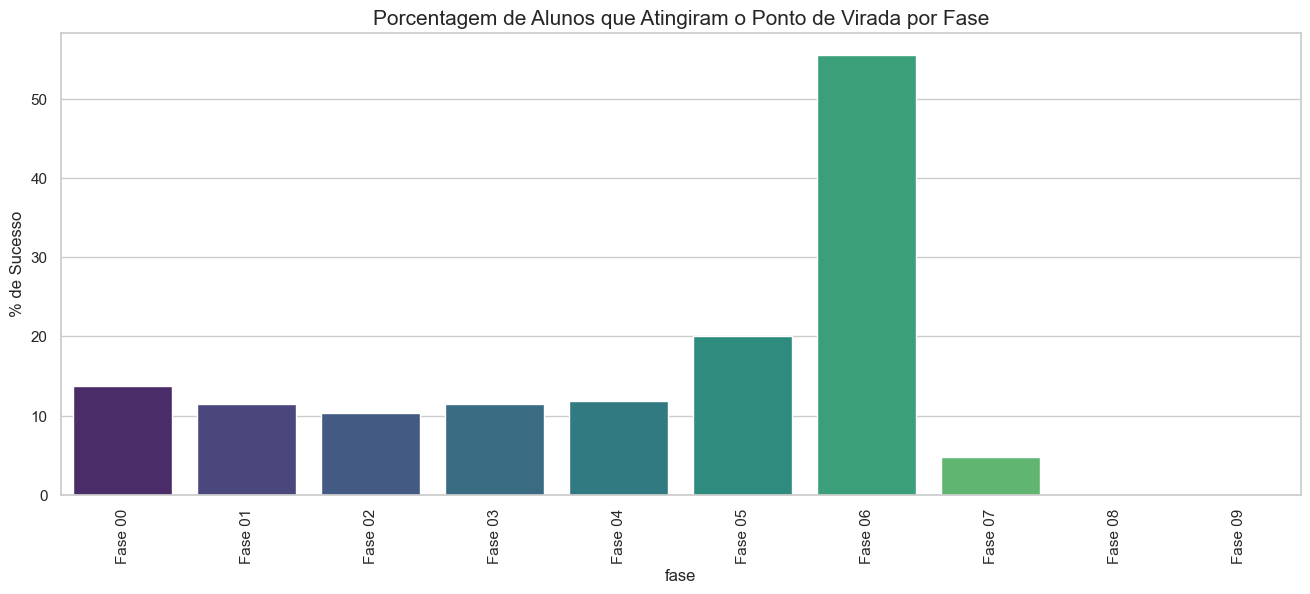

C:\Users\jgmoraes\AppData\Local\Temp\ipykernel_25400\1552785821.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_base, x='indicado_pv', y='ind_pv', palette='Set2')


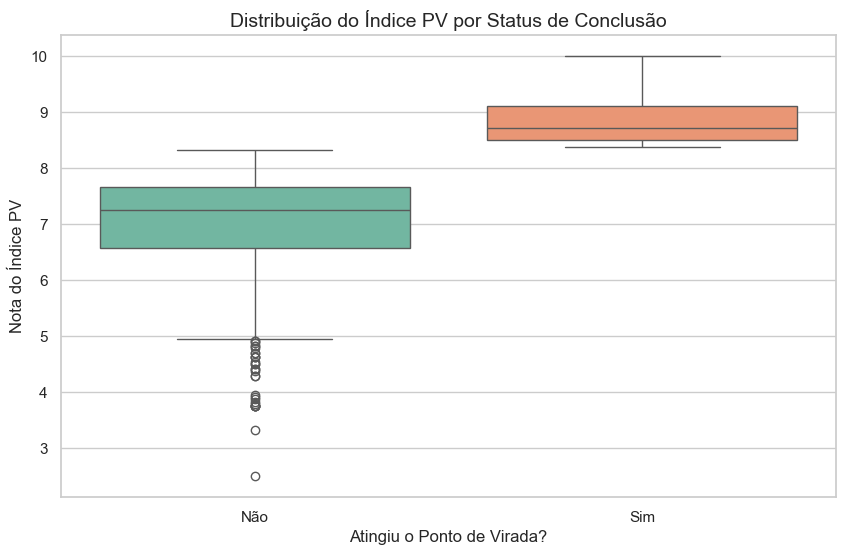

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TAXA DE SUCESSO (Usando 'indicado_pv')
# Transformando Sim/Não em 1/0
df_base['pv_binary'] = df_base['indicado_pv'].map({'Sim': 1, 'Não': 0, 'SIM': 1, 'NÃO': 0, True: 1, False: 0})

plt.figure(figsize=(16, 6))
pv_fase = df_base.groupby('fase')['pv_binary'].mean() * 100
sns.barplot(x=pv_fase.index, y=pv_fase.values, palette='viridis')
plt.title('Porcentagem de Alunos que Atingiram o Ponto de Virada por Fase', fontsize=15)
plt.ylabel('% de Sucesso')
plt.xticks(rotation=90)
plt.show()

# 2. MÉTRICA VS RESULTADO (Usando 'ind_pv' e 'indicado_pv')
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_base, x='indicado_pv', y='ind_pv', palette='Set2')
plt.title('Distribuição do Índice PV por Status de Conclusão', fontsize=14)
plt.xlabel('Atingiu o Ponto de Virada?')
plt.ylabel('Nota do Índice PV')
plt.show()

## Sobre os gráficos acima

1. Objetivo da Análise
O propósito deste bloco foi identificar e mensurar o "Ponto de Virada" — um indicador exclusivo da Passos Mágicos que sinaliza quando o aluno atinge um nível de maturidade e conscientização que impulsiona seu desenvolvimento. Analisamos em qual estágio escolar isso ocorre com mais frequência e como o índice técnico (IPV) se comporta em relação ao status final.

2. Metodologia e Processamento
Conversão Binária: Transformamos o campo indicado_pv (Sim/Não) em valores numéricos (1/0) para calcular a taxa percentual de sucesso por fase.

Cruzamento de Indicadores: Utilizamos o ind_pv (Índice de Ponto de Virada), que é uma nota contínua, para validar se quem foi classificado com o Ponto de Virada atingido possui, estatisticamente, notas superiores aos demais.

Visualização de Distribuição: Aplicamos um boxplot para enxergar a dispersão e a mediana das notas técnicas entre os grupos que atingiram ou não o objetivo.

3. Interpretação dos Gráficos
O "Ápice" na Fase 06: O gráfico de barras revela um comportamento muito interessante: o Ponto de Virada tem um crescimento constante até a Fase 05, mas apresenta um salto dramático na Fase 06, onde mais de 50% dos alunos atingem esse marco. Isso indica que esta fase é o momento de maior maturação do método pedagógico.

Validação Técnica: O gráfico de boxplot confirma que a classificação é precisa. A mediana da nota técnica (ind_pv) de quem atingiu o ponto de virada está próxima de 9.0, enquanto a de quem não atingiu flutua em torno de 7.0.

Outliers de Potencial: Notamos alguns alunos que, mesmo sem o selo oficial de "Atingiu", já possuem notas técnicas muito altas (pontos acima da caixa no grupo "Não"). Estes são alunos que estão "prestes a virar a chave" e devem receber atenção especial.

4. Insight para o Storytelling
"O Ponto de Virada é a prova de que a educação transforma o caráter e a ambição do aluno. Nossos dados mostram que a Fase 06 é o divisor de águas: é onde o aluno deixa de ser apenas um estudante e passa a ser o protagonista de sua história. Validamos que esse status não é subjetivo, pois é acompanhado por um salto real na nota técnica. Para a ONG, o insight é claro: os esforços das fases iniciais preparam o terreno para a explosão de consciência que ocorre no Ensino Fundamental II."